<a href="https://colab.research.google.com/github/A1phar1u5/FuzzyLSTM_With_Indicators_Test_System/blob/main/Statistical_tests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Загрузка библитоек и данных

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
# Установка scikit-posthocs
!pip install scikit-posthocs -q
import scikit_posthocs as sp

In [ ]:
# Загрузка данных
df = pd.read_csv('registry2.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   model               125 non-null    object 
 1   ticker              125 non-null    object 
 2   step                125 non-null    object 
 3   lookback            125 non-null    int64  
 4   units               125 non-null    int64  
 5   window              125 non-null    int64  
 6   seed                125 non-null    int64  
 7   rmse_train          125 non-null    float64
 8   mae_train           125 non-null    float64
 9   mape_train          125 non-null    float64
 10  rmse_test           125 non-null    float64
 11  mae_test            125 non-null    float64
 12  mape_test           125 non-null    float64
 13  train_time_s        125 non-null    float64
 14  infer_time_train_s  125 non-null    float64
 15  infer_time_test_s   125 non-null    float64
 16  ts      

## Время обучения

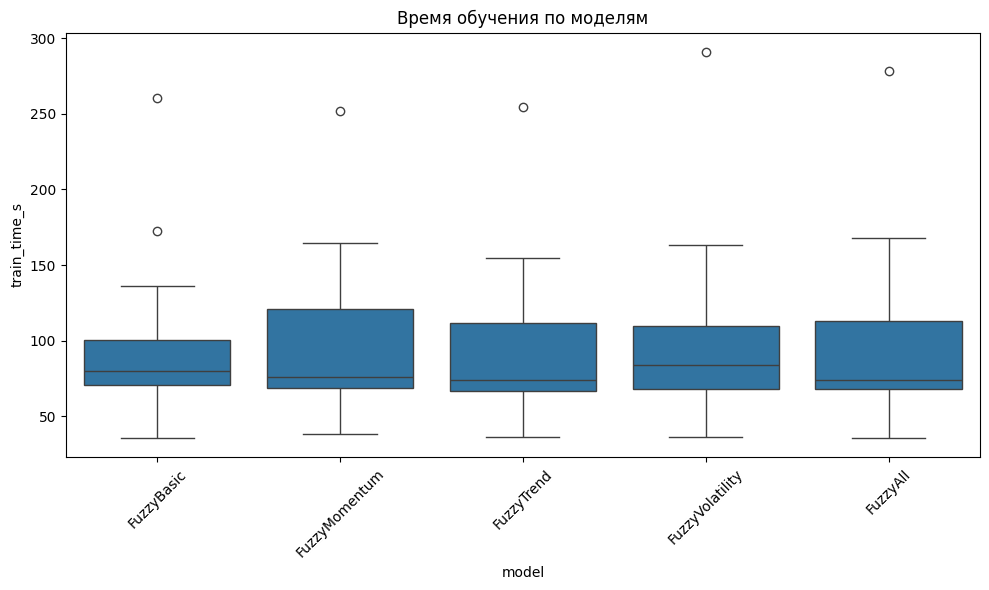

In [ ]:
# Шаг 1: Визуализация
plt.figure(figsize=(10, 6))
sns.boxplot(x='model', y='train_time_s', data=df)
plt.title('Время обучения по моделям')
plt.ylabel('train_time_s')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('boxplot_train_time.png')
plt.show()

In [ ]:
# Шаг 2: Проверка предположений ANOVA
models = df['model'].unique()
groups = {m: df[df['model'] == m]['train_time_s'].values for m in models}

# Нормальность (Shapiro-Wilk)
print("=== Shapiro-Wilk (нормальность) ===")
for m, vals in groups.items():
    stat, p = stats.shapiro(vals)
    print(f"{m:20s}: W={stat:.4f}, p={p:.4f} {'✓' if p > 0.05 else '✗'}")

# Гомогенность дисперсий (Levene)
print("\n=== Levene (гомогенность дисперсий) ===")
stat, p = stats.levene(*groups.values())
print(f"Levene: stat={stat:.4f}, p={p:.4f} {'✓' if p > 0.05 else '✗'}")

=== Shapiro-Wilk (нормальность) ===
FuzzyBasic          : W=0.8012, p=0.0002 ✗
FuzzyMomentum       : W=0.8216, p=0.0005 ✗
FuzzyTrend          : W=0.8158, p=0.0004 ✗
FuzzyVolatility     : W=0.7843, p=0.0001 ✗
FuzzyAll            : W=0.7896, p=0.0002 ✗

=== Levene (гомогенность дисперсий) ===
Levene: stat=0.0317, p=0.9980 ✓


In [ ]:
# Выбор и выполнение теста
if p > 0.05 and all(stats.shapiro(v)[1] > 0.05 for v in groups.values()):
    # ANOVA + Tukey
    stat, p_anova = stats.f_oneway(*groups.values())
    print(f"\n=== One-way ANOVA: F={stat:.4f}, p={p_anova:.6f} ===")
    if p_anova < 0.05:
        from statsmodels.stats.multicomp import pairwise_tukeyhsd
        tukey = pairwise_tukeyhsd(df['train_time_s'], df['model'], alpha=0.05)
        print(tukey)
else:
    # Kruskal-Wallis + Dunn
    stat, p_kw = stats.kruskal(*groups.values())
    print(f"\n=== Kruskal-Wallis: H={stat:.4f}, p={p_kw:.6f} ===")
    if p_kw < 0.05:
        import scikit_posthocs as sp
        dunn = sp.posthoc_dunn(df, val_col='train_time_s', group_col='model', p_adjust='bonferroni')
        print("\n=== Dunn's test (p-values) ===")
        print(dunn.round(4))


=== Kruskal-Wallis: H=0.6914, p=0.952387 ===


## Метрика ошибки RMSE

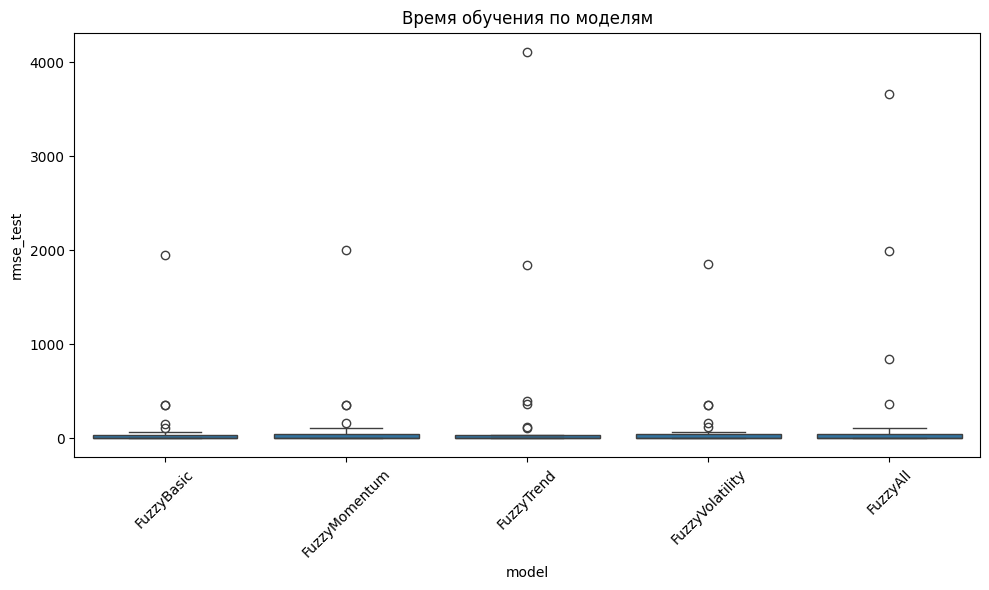

In [ ]:
# Шаг 1: Визуализация
plt.figure(figsize=(10, 6))
sns.boxplot(x='model', y='rmse_test', data=df)
plt.title('Время обучения по моделям')
plt.ylabel('rmse_test')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('boxplot_train_time.png')
plt.show()

In [ ]:
# Шаг 2: Проверка предположений ANOVA
models = df['model'].unique()
groups = {m: df[df['model'] == m]['rmse_test'].values for m in models}

# Нормальность (Shapiro-Wilk)
print("=== Shapiro-Wilk (нормальность) ===")
for m, vals in groups.items():
    stat, p = stats.shapiro(vals)
    print(f"{m:20s}: W={stat:.4f}, p={p:.4f} {'✓' if p > 0.05 else '✗'}")

# Гомогенность дисперсий (Levene)
print("\n=== Levene (гомогенность дисперсий) ===")
stat, p = stats.levene(*groups.values())
print(f"Levene: stat={stat:.4f}, p={p:.4f} {'✓' if p > 0.05 else '✗'}")

=== Shapiro-Wilk (нормальность) ===
FuzzyBasic          : W=0.3467, p=0.0000 ✗
FuzzyMomentum       : W=0.3453, p=0.0000 ✗
FuzzyTrend          : W=0.3679, p=0.0000 ✗
FuzzyVolatility     : W=0.3565, p=0.0000 ✗
FuzzyAll            : W=0.4108, p=0.0000 ✗

=== Levene (гомогенность дисперсий) ===
Levene: stat=0.5157, p=0.7243 ✓


In [ ]:
# Выбор и выполнение теста
if p > 0.05 and all(stats.shapiro(v)[1] > 0.05 for v in groups.values()):
    # ANOVA + Tukey
    stat, p_anova = stats.f_oneway(*groups.values())
    print(f"\n=== One-way ANOVA: F={stat:.4f}, p={p_anova:.6f} ===")
    if p_anova < 0.05:
        from statsmodels.stats.multicomp import pairwise_tukeyhsd
        tukey = pairwise_tukeyhsd(df['train_time_s'], df['model'], alpha=0.05)
        print(tukey)
else:
    # Kruskal-Wallis + Dunn
    stat, p_kw = stats.kruskal(*groups.values())
    print(f"\n=== Kruskal-Wallis: H={stat:.4f}, p={p_kw:.6f} ===")
    if p_kw < 0.05:
        import scikit_posthocs as sp
        dunn = sp.posthoc_dunn(df, val_col='train_time_s', group_col='model', p_adjust='bonferroni')
        print("\n=== Dunn's test (p-values) ===")
        print(dunn.round(4))


=== Kruskal-Wallis: H=0.2275, p=0.993999 ===


## Метрика ошибки MAE

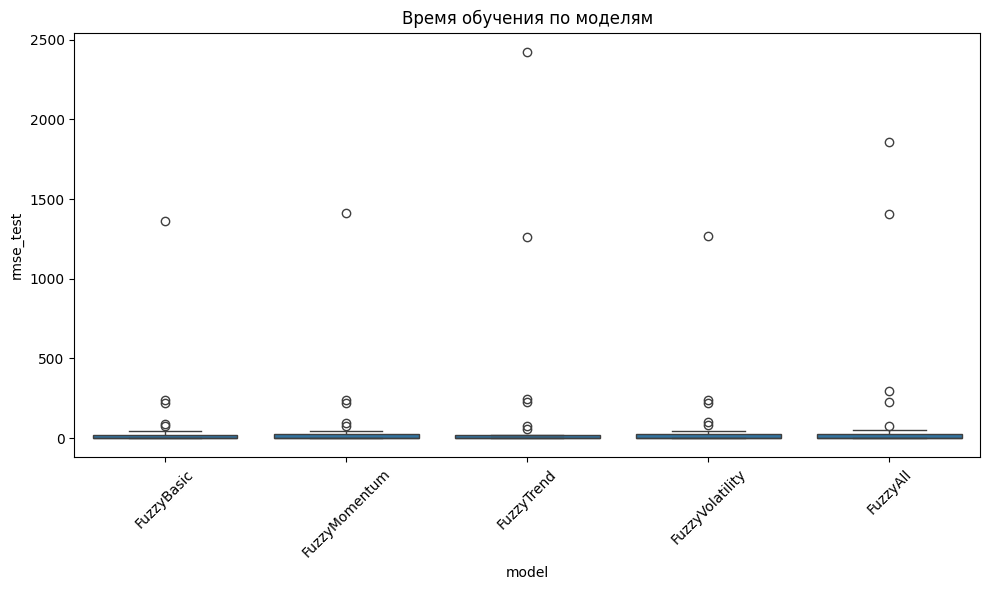

In [ ]:
# Шаг 1: Визуализация
plt.figure(figsize=(10, 6))
sns.boxplot(x='model', y='mae_test', data=df)
plt.title('Время обучения по моделям')
plt.ylabel('rmse_test')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('boxplot_train_time.png')
plt.show()

In [ ]:
# Шаг 2: Проверка предположений ANOVA
models = df['model'].unique()
groups = {m: df[df['model'] == m]['mae_test'].values for m in models}

# Нормальность (Shapiro-Wilk)
print("=== Shapiro-Wilk (нормальность) ===")
for m, vals in groups.items():
    stat, p = stats.shapiro(vals)
    print(f"{m:20s}: W={stat:.4f}, p={p:.4f} {'✓' if p > 0.05 else '✗'}")

# Гомогенность дисперсий (Levene)
print("\n=== Levene (гомогенность дисперсий) ===")
stat, p = stats.levene(*groups.values())
print(f"Levene: stat={stat:.4f}, p={p:.4f} {'✓' if p > 0.05 else '✗'}")

=== Shapiro-Wilk (нормальность) ===
FuzzyBasic          : W=0.3375, p=0.0000 ✗
FuzzyMomentum       : W=0.3357, p=0.0000 ✗
FuzzyTrend          : W=0.3763, p=0.0000 ✗
FuzzyVolatility     : W=0.3503, p=0.0000 ✗
FuzzyAll            : W=0.4039, p=0.0000 ✗

=== Levene (гомогенность дисперсий) ===
Levene: stat=0.3696, p=0.8299 ✓


In [ ]:
# Выбор и выполнение теста
if p > 0.05 and all(stats.shapiro(v)[1] > 0.05 for v in groups.values()):
    # ANOVA + Tukey
    stat, p_anova = stats.f_oneway(*groups.values())
    print(f"\n=== One-way ANOVA: F={stat:.4f}, p={p_anova:.6f} ===")
    if p_anova < 0.05:
        from statsmodels.stats.multicomp import pairwise_tukeyhsd
        tukey = pairwise_tukeyhsd(df['train_time_s'], df['model'], alpha=0.05)
        print(tukey)
else:
    # Kruskal-Wallis + Dunn
    stat, p_kw = stats.kruskal(*groups.values())
    print(f"\n=== Kruskal-Wallis: H={stat:.4f}, p={p_kw:.6f} ===")
    if p_kw < 0.05:
        import scikit_posthocs as sp
        dunn = sp.posthoc_dunn(df, val_col='train_time_s', group_col='model', p_adjust='bonferroni')
        print("\n=== Dunn's test (p-values) ===")
        print(dunn.round(4))


=== Kruskal-Wallis: H=0.3123, p=0.989009 ===


## Метрика ошибки MAPE

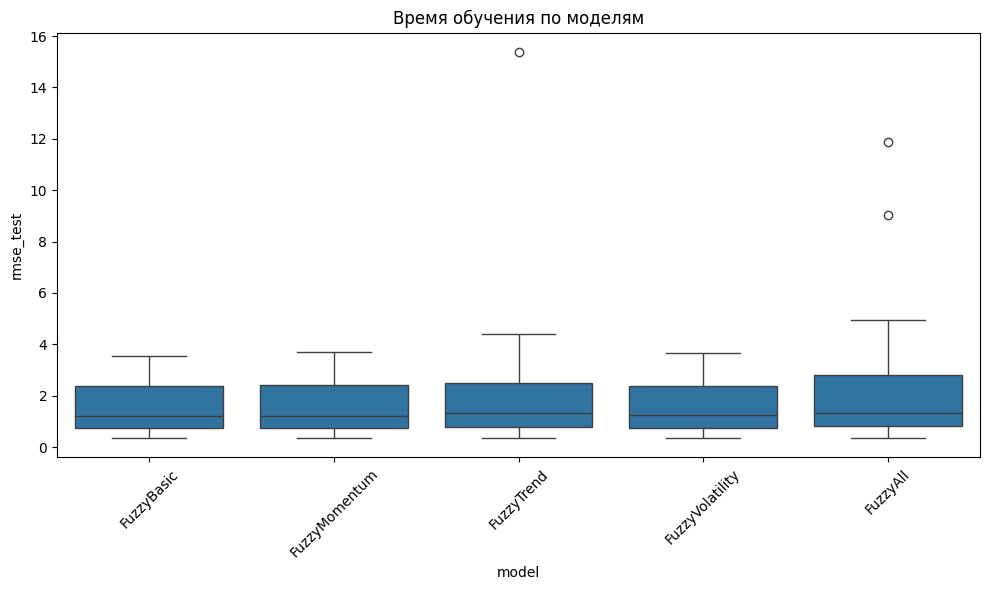

In [ ]:
# Шаг 1: Визуализация
plt.figure(figsize=(10, 6))
sns.boxplot(x='model', y='mape_test', data=df)
plt.title('Время обучения по моделям')
plt.ylabel('rmse_test')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('boxplot_train_time.png')
plt.show()

In [ ]:
# Шаг 2: Проверка предположений ANOVA
models = df['model'].unique()
groups = {m: df[df['model'] == m]['mape_test'].values for m in models}

# Нормальность (Shapiro-Wilk)
print("=== Shapiro-Wilk (нормальность) ===")
for m, vals in groups.items():
    stat, p = stats.shapiro(vals)
    print(f"{m:20s}: W={stat:.4f}, p={p:.4f} {'✓' if p > 0.05 else '✗'}")

# Гомогенность дисперсий (Levene)
print("\n=== Levene (гомогенность дисперсий) ===")
stat, p = stats.levene(*groups.values())
print(f"Levene: stat={stat:.4f}, p={p:.4f} {'✓' if p > 0.05 else '✗'}")

=== Shapiro-Wilk (нормальность) ===
FuzzyBasic          : W=0.9054, p=0.0241 ✗
FuzzyMomentum       : W=0.9035, p=0.0219 ✗
FuzzyTrend          : W=0.5301, p=0.0000 ✗
FuzzyVolatility     : W=0.9039, p=0.0224 ✗
FuzzyAll            : W=0.6966, p=0.0000 ✗

=== Levene (гомогенность дисперсий) ===
Levene: stat=1.2064, p=0.3117 ✓


In [ ]:
# Выбор и выполнение теста
if p > 0.05 and all(stats.shapiro(v)[1] > 0.05 for v in groups.values()):
    # ANOVA + Tukey
    stat, p_anova = stats.f_oneway(*groups.values())
    print(f"\n=== One-way ANOVA: F={stat:.4f}, p={p_anova:.6f} ===")
else:
    # Kruskal-Wallis + Dunn
    stat, p_kw = stats.kruskal(*groups.values())
    print(f"\n=== Kruskal-Wallis: H={stat:.4f}, p={p_kw:.6f} ===")


=== Kruskal-Wallis: H=1.1903, p=0.879687 ===


## Сравнение категорий

In [ ]:
def categorize(ticker):
    if ticker in ['AAPL', 'INTC', 'TSLA', 'NVDA', 'MSFT']:
        return 'Акции'
    elif '=X' in ticker:
        return 'Валюты'
    elif '-USD' in ticker:
        return 'Криптовалюты'
    elif ticker.startswith('^'):
        return 'Индексы'
    else:
        return 'Фьючерсы'

df['category'] = df['ticker'].apply(categorize)

metrics = ['rmse_test', 'mae_test', 'mape_test']

cats = ['Акции', 'Валюты', 'Криптовалюты', 'Индексы', 'Фьючерсы']

In [ ]:
for metric in metrics:
    print(f"\n{'='*60}")
    print(f"  {metric.upper()} по категориям")

    for cat in cats:
        cat_df = df[df['category'] == cat]
        models_in_cat = cat_df['model'].unique()
        groups = [cat_df[cat_df['model'] == m][metric].dropna().values
                  for m in models_in_cat]
        groups = [g for g in groups if len(g) >= 3]
        if len(groups) < 2:
            continue

        _, p_lev = stats.levene(*groups)
        H, p_kw = stats.kruskal(*groups)

        print(f"\n{cat}: H={H:.2f}, p={p_kw:.6f} | Levene p={p_lev:.4f}")
        if p_kw < 0.05:
            dunn = sp.posthoc_dunn(cat_df, val_col=metric, group_col='model', p_adjust='bonferroni')
            print(dunn.round(4))


  RMSE_TEST по категориям

Акции: H=1.05, p=0.902337 | Levene p=0.6780

Валюты: H=0.20, p=0.995349 | Levene p=1.0000

Криптовалюты: H=0.12, p=0.998322 | Levene p=1.0000

Индексы: H=3.05, p=0.549519 | Levene p=0.4552

Фьючерсы: H=0.46, p=0.977473 | Levene p=1.0000

  MAE_TEST по категориям

Акции: H=1.57, p=0.813650 | Levene p=0.9225

Валюты: H=0.21, p=0.995010 | Levene p=1.0000

Криптовалюты: H=0.13, p=0.998111 | Levene p=1.0000

Индексы: H=2.02, p=0.732816 | Levene p=0.5083

Фьючерсы: H=0.86, p=0.930701 | Levene p=1.0000

  MAPE_TEST по категориям

Акции: H=1.12, p=0.891873 | Levene p=0.5843

Валюты: H=0.18, p=0.996298 | Levene p=0.9999

Криптовалюты: H=1.12, p=0.891873 | Levene p=0.7753

Индексы: H=5.20, p=0.267504 | Levene p=0.5740

Фьючерсы: H=0.42, p=0.980728 | Levene p=0.9998
